Tsunami DB summary


In [1]:
import pandas as pd
import numpy as np

BSfile = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/processed/eve_BS.txt'
PSfile = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/processed/eve_PS_SourceRegion.txt'

# Read the data
BSdata = pd.read_csv(BSfile, sep='\t')
PSdata = pd.read_csv(PSfile, sep='\t')

#Get data range for each column
BSdata.describe()
PSdata.describe()


,Mag,Long,Lat
count,28509.000000,28509.000000,28509.000000
mean,8.388175,21.408245,36.008372
std,0.461733,2.363519,1.184911
min,6.500000,15.470000,33.620000
25%,8.090000,20.780000,35.010000
50%,8.610000,21.990000,35.830000
75%,8.710000,22.960000,36.900000
max,9.020000,32.910000,38.930000


Max Amp and Amp Ratio from offshore statistics and onshore statistics

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Load common data from your selected stations
max_amp_file = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/grid0_allpts87_alleve53550.offshore.txt'
waveperiod_file = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/grid0_allpts87_alleveWP53550.offshore.txt'
dominant_period_file = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/grid0_allpts87_alleveDP53550.offshore.txt'
df_amp = pd.read_csv(max_amp_file, sep='\t')
df_wp = pd.read_csv(waveperiod_file, sep='\t')
df_dp = pd.read_csv(dominant_period_file, sep='\t')
id = df_amp.iloc[:, 0]

#CT-df
st = 38 #38/41 for CT and 54 for SR
# Extract the data for the selected station
max_amp = df_amp.iloc[:, st]
waveperiod = df_wp.iloc[:, st]
dominantperiod = df_dp.iloc[:, st]

max_ht_file = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/CHeight_CT_alleve53550.onshore.txt'
df_ht = pd.read_csv(max_ht_file, sep='\t')
max_ht = df_ht['hmax']
max_depth = df_ht['dmax']
#abs max of dzmin or dzmax
max_adz = df_ht[['dzmax', 'dzmin']].abs().max(axis=1)

# Create a DataFrame for the selected station
df = pd.DataFrame({'id': id,
                'max_amp': max_amp,
                'waveperiod': waveperiod,
                'dominantperiod': dominantperiod,
                'max_ht': max_ht,
                'max_adz': max_adz,
                'max_depth': max_depth})

# Split the first 2 characters of id into a new column 'type'
df['type'] = df['id'].str[:2]
df['amp_ratio'] = df['max_ht']/df['max_amp']

#filter events with max_adz < 0.1
# df = df[df['max_adz'] < 0.1]
# df = df[df['max_amp'] > 0.1]

#SR-df2
st = 54
# Extract the data for the selected station
max_amp = df_amp.iloc[:, st]
waveperiod = df_wp.iloc[:, st]
dominantperiod = df_dp.iloc[:, st]
max_ht_file = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/CHeight_SR_alleve53550.onshore.txt'
df2_ht = pd.read_csv(max_ht_file, sep='\t')
max_ht = df2_ht['hmax']
max_depth = df2_ht['dmax']
#abs max of dzmin or dzmax
max_adz = df2_ht[['dzmax', 'dzmin']].abs().max(axis=1)#abs max of dzmin or dzmax

# Create a DataFrame for the selected station
df2 = pd.DataFrame({'id': id,
                    'max_amp': max_amp,
                    'waveperiod': waveperiod,
                    'dominantperiod': dominantperiod,
                    'max_ht': max_ht,
                    'max_adz': max_adz,
                    'max_depth': max_depth})

# Split the first 2 characters of id into a new column 'type'
df2['type'] = df2['id'].str[:2]
df2['amp_ratio'] = df2['max_ht']/df2['max_amp']

#filter events with max_adz < 0.1
# df2 = df2[df2['max_adz'] < 0.1]
# df2 = df2[df2['max_amp'] > 0.1]


Type vs Magnitude

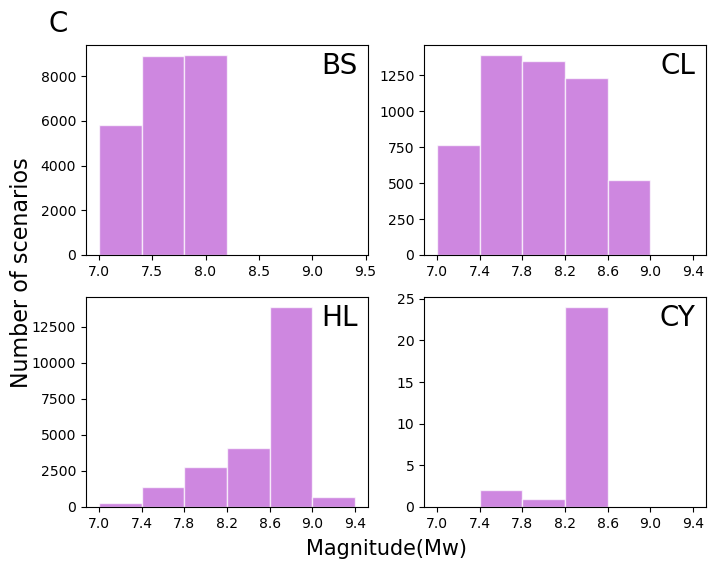

In [7]:
import matplotlib.pyplot as plt

# Read earthquake events data from txt files
data_BS = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/processed/eve_BS.txt',sep='\t')
data_PS = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/processed/eve_PS_SourceRegion.txt',sep='\t')

#plot historgram across source regions of the magnitude
bins = np.arange( 7.0,  9.4, 0.4)
fig, ax = plt.subplots(2,2,figsize=(8,6))

#plot as subplots
ax[0,0].hist(data_BS['Mag'], bins = bins, facecolor='mediumorchid', align='mid',edgecolor='white',alpha=0.7)
ax[0,1].hist(data_PS[data_PS['SR']=='CL']['Mag'], bins = bins, facecolor='mediumorchid', align='mid',edgecolor='white',alpha=0.7)
ax[1,0].hist(data_PS[data_PS['SR']=='HL']['Mag'], bins = bins, facecolor='mediumorchid', align='mid',edgecolor='white',alpha=0.7)
ax[1,1].hist(data_PS[data_PS['SR']=='CY']['Mag'], bins = bins, facecolor='mediumorchid', align='mid',edgecolor='white',alpha=0.7)

#set common xlabel and ticks
ax[0,1].set_xticks(bins)
ax[1,0].set_xticks(bins)
ax[1,1].set_xticks(bins)
ax[1,0].set_xticks(bins)

#set labels
ax[0,0].text(-0.1,1.1,'C',horizontalalignment='center',verticalalignment='center',transform=ax[0,0].transAxes,fontsize=20)
# # ax[0,1].text(-0.1,1.1,'B',horizontalalignment='center',verticalalignment='center',transform=ax[0,1].transAxes,fontsize=20)
# # ax[1,0].text(-0.1,1.1,'C',horizontalalignment='center',verticalalignment='center',transform=ax[1,0].transAxes,fontsize=20)
# # ax[1,1].text(-0.1,1.1,'D',horizontalalignment='center',verticalalignment='center',transform=ax[1,1].transAxes,fontsize=20)

#set labels
ax[0,0].text(0.9,0.9,'BS',horizontalalignment='center',verticalalignment='center',transform=ax[0,0].transAxes,fontsize=20)
ax[0,1].text(0.9,0.9,'CL',horizontalalignment='center',verticalalignment='center',transform=ax[0,1].transAxes,fontsize=20)
ax[1,0].text(0.9,0.9,'HL',horizontalalignment='center',verticalalignment='center',transform=ax[1,0].transAxes,fontsize=20)
ax[1,1].text(0.9,0.9,'CY',horizontalalignment='center',verticalalignment='center',transform=ax[1,1].transAxes,fontsize=20)

#common x and y label
fig.text(0.03, 0.5, 'Number of scenarios', va='center', rotation='vertical', fontsize = 16)
fig.text(0.5, 0.03, 'Magnitude(Mw)', ha='center', fontsize = 15)

#save figure
plt.savefig('./earthquake_mag_bysource.png', dpi=600, bbox_inches='tight')

Train vs Test

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
list_size_CT = ['225', '529','892','1658','3454','7071'][3] #Size to plot 
list_size_SR = ['228', '550' ,'961','1773','3669','6941'][3]
train_df_CT = pd.DataFrame()
train_df_SR = pd.DataFrame()
eve_perf_CT = pd.read_csv(f'{MLDir}/model/CT/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size_CT}_compile_combined.csv')
eve_perf_SR = pd.read_csv(f'{MLDir}/model/SR/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size_SR}_compile_combined.csv')
eve_perf_CT=eve_perf_CT[eve_perf_CT['split'] == 'train']
eve_perf_SR=eve_perf_SR[eve_perf_SR['split'] == 'train']

#update split column with size instead
eve_perf_CT['size'] = list_size_CT
eve_perf_SR['size'] = list_size_CT
#append as rows
train_df_CT = pd.concat([train_df_CT,eve_perf_CT])
train_df_SR = pd.concat([train_df_SR,eve_perf_SR])
variables = ['max_absdz','max_off','true','truemax']


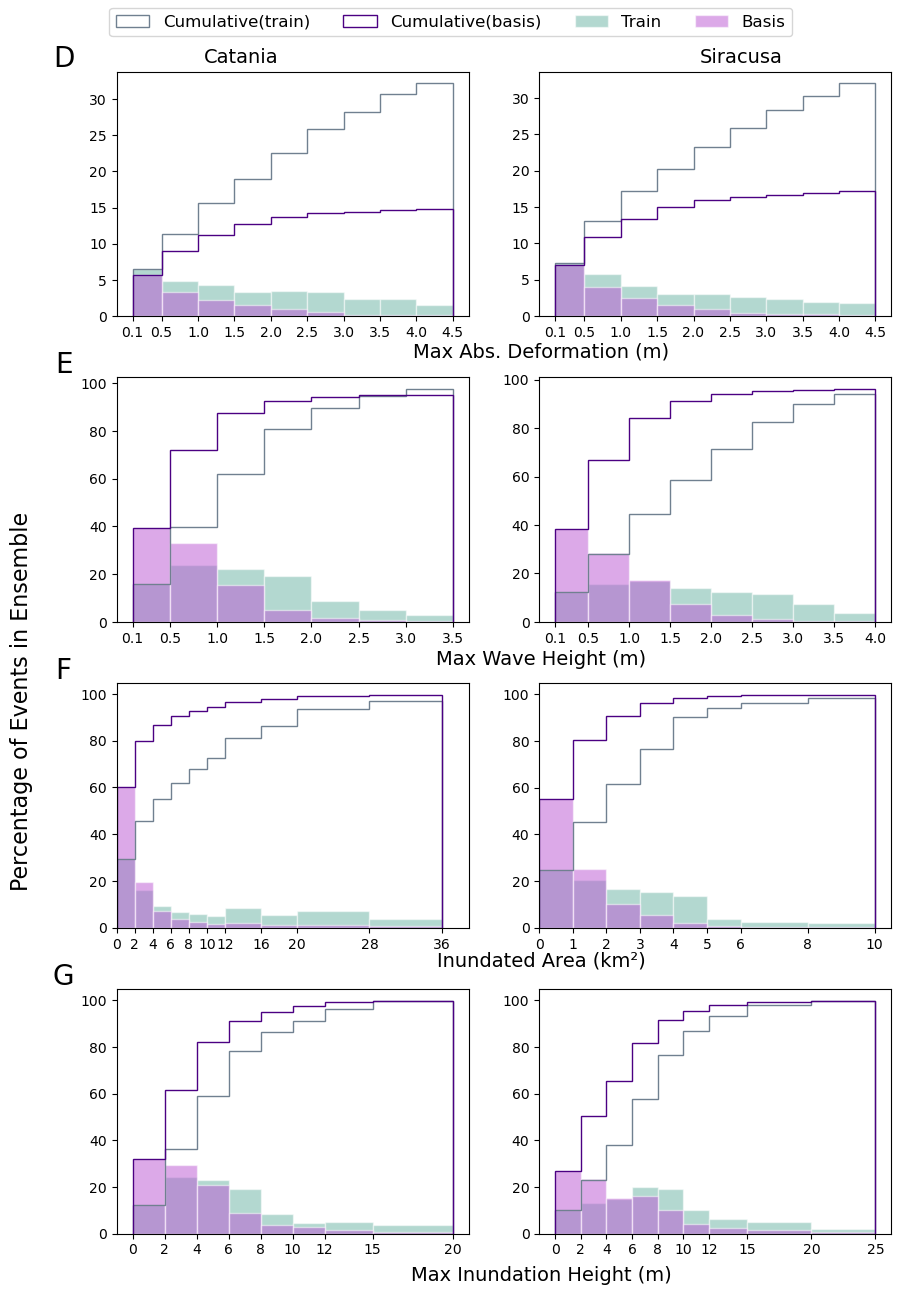

In [ ]:
def plot_hist(ax, basis, train, bins):
    ax.hist(train,
            weights=100.0 * np.ones(len(train)) / len(train),
            bins=bins, align='mid',
            histtype='step', label='Cumulative(train)',
            cumulative=True,
            color='slategrey'
            ) 
    ax.hist(basis,
            weights=100.0 * np.ones(len(basis)) / len(basis),
            bins=bins, align='mid',
            histtype='step', label='Cumulative(basis)',
            cumulative=True,
            color='indigo'
            )
#     ax.hist(data,
#             weights=100.0 * np.ones(len(data)) / len(data),
#             bins=bins, align='mid',
#             histtype='step', label='Reverse Cumulative',
#             cumulative=-1)
    ax.hist(train,
            weights=100.0 * np.ones(len(train)) / len(train),
            bins=bins, align='mid', facecolor='#69b3a2',
            edgecolor='white',
            label='Train',
            cumulative=False,alpha=0.5)
    ax.hist(basis,
            weights=100.0 * np.ones(len(basis)) / len(basis),
            bins=bins, align='mid', facecolor='mediumorchid',
            edgecolor='white',
            label='Basis',
            cumulative=False,alpha=0.5)
    ax.set_xticks(bins)
    ax.set_ylabel('')

fig, ax = plt.subplots(4, 2, figsize=(10, 14))
ax = ax.flatten()
row_titles = ['Max Abs. Deformation (m)', 'Max Wave Height (m)', 'Inundated Area (km²)', 'Max Inundation Height (m)']

# Max Absolute Deformation
bins_CT = np.concatenate((np.arange(0.1, 0.1, 0.1), np.arange(0.1, 0.5, 0.5), np.arange(0.5, 5, 0.5)))
bins_SR = bins_CT

plot_hist(ax[0], df['max_adz'],train_df_CT['max_absdz'], bins_CT) 
plot_hist(ax[1], df2['max_adz'],train_df_SR['max_absdz'], bins_SR)

# Max Wave Height
bins_CT = np.concatenate((np.arange(0.1, 0.1, 0.1), np.arange(0.1, 0.5, 0.5), np.arange(0.5, 4, 0.5)))
bins_SR = np.concatenate((np.arange(0.1, 0.1, 0.1), np.arange(0.1, 0.5, 0.5), np.arange(0.5, 4.5, 0.5 )))

plot_hist(ax[2], df['max_amp'],train_df_CT['max_off'], bins_CT) 
plot_hist(ax[3], df2['max_amp'],train_df_SR['max_off'], bins_SR)

# Inundated Area
bins_CT = np.concatenate((np.arange(0.0, 12, 2), np.arange(12, 20, 4), np.arange(20, 42, 8)))
bins_SR = np.concatenate((np.arange(0, 4, 1), np.arange(4, 6, 1), np.arange(6, 12, 2)))

plot_hist(ax[4], df_ht['count'] * 0.0001, train_df_CT['true']* 0.0001, bins_CT)
plot_hist(ax[5], df2_ht['count'] * 0.0001, train_df_SR['true']* 0.0001, bins_SR)

ax[4].set_xlim(0, 39)
ax[5].set_xlim(0, 10.5)

# Max Inundation Height
bins_CT = np.concatenate((np.arange(0.0, 12, 2), np.arange(12, 15, 3), np.arange(15, 25, 5)))
bins_SR = np.concatenate((np.arange(0.0, 12, 2), np.arange(12, 15, 3), np.arange(15, 30, 5)))

plot_hist(ax[6], df_ht['hmax'],train_df_CT['truemax'], bins_CT)
plot_hist(ax[7], df2_ht['hmax'], train_df_SR['truemax'], bins_SR)
# Common y-label
fig.text(0.03, 0.5, 'Percentage of Events in Ensemble', ha='center', va='center', rotation='vertical', fontsize=16)

# Common x-labels for each row
fig.text(0.55, 0.75, row_titles[0], ha='center', va='center', fontsize=14) 
fig.text(0.55, 0.53, row_titles[1], ha='center', va='center', fontsize=14) 
fig.text(0.55, 0.315, row_titles[2], ha='center', va='center', fontsize=14) 
fig.text(0.55, 0.09, row_titles[3], ha='center', va='center', fontsize=14) 

#set labels
ax[0].text(-0.15,1.05,'D',horizontalalignment='center',verticalalignment='center',transform=ax[0].transAxes,fontsize=20)
ax[2].text(-0.15,1.05,'E',horizontalalignment='center',verticalalignment='center',transform=ax[2].transAxes,fontsize=20)
ax[4].text(-0.15,1.05,'F',horizontalalignment='center',verticalalignment='center',transform=ax[4].transAxes,fontsize=20)
ax[6].text(-0.15,1.05,'G',horizontalalignment='center',verticalalignment='center',transform=ax[6].transAxes,fontsize=20)

# Add label of sites on the top of each column
fig.text(0.25, .96, 'Catania', ha='center', va='center', fontsize=14)
fig.text(0.75, .96, 'Siracusa', ha='center', va='center', fontsize=14)

# # Collect all handles and labels for legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', fontsize=12, ncol=4)
plt.subplots_adjust(top=0.95, bottom=0.12, hspace=0.25, wspace=0.2)
plt.savefig('./combined_hist_3pt3_perc.png', dpi=600, bbox_inches='tight')


In [20]:
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
list_size_CT = ['225', '529','892','1658','3454','7071']
list_size_SR = ['228', '550' ,'961','1773','3669','6941']
train_df_CT = pd.DataFrame()
train_df_SR = pd.DataFrame()
for size in range(len(list_size_CT)):
    eve_perf_CT = pd.read_csv(f'{MLDir}/model/CT/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size_CT[size]}_compile_combined.csv')
    eve_perf_SR = pd.read_csv(f'{MLDir}/model/SR/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size_SR[size]}_compile_combined.csv')
    eve_perf_CT=eve_perf_CT[eve_perf_CT['split'] == 'train']
    eve_perf_SR=eve_perf_SR[eve_perf_SR['split'] == 'train']
    #update split column with size instead
    eve_perf_CT['size'] = str(size)
    eve_perf_SR['size'] = str(size)
    #append as rows
    train_df_CT = pd.concat([train_df_CT,eve_perf_CT])
    train_df_SR = pd.concat([train_df_SR,eve_perf_SR])
eve_perf_CT = pd.read_csv(f'{MLDir}/model/CT/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size_CT[size]}_compile_combined.csv')
eve_perf_SR = pd.read_csv(f'{MLDir}/model/SR/multifoldMC/out/model_direct_off[64, 128, 256]_on[16, 128, 128]_{list_size_SR[size]}_compile_combined.csv')
eve_perf_CT['split'] = 'basis'
eve_perf_SR['split'] = 'basis'
eve_perf_CT['size'] = 'basis'
eve_perf_SR['size'] = 'basis'
#append as rows
train_df_CT = pd.concat([train_df_CT,eve_perf_CT])
train_df_SR = pd.concat([train_df_SR,eve_perf_SR])
variables = ['true','truemax','max_off','dominant_period','max_absdz','Mag']
labels = ['Inundated grids(count)','Max inun. Depth(m)','Max wave height(m)','Dominant Period(min)','Max Abs Displacement(m)','EQ Mag(Mw)']

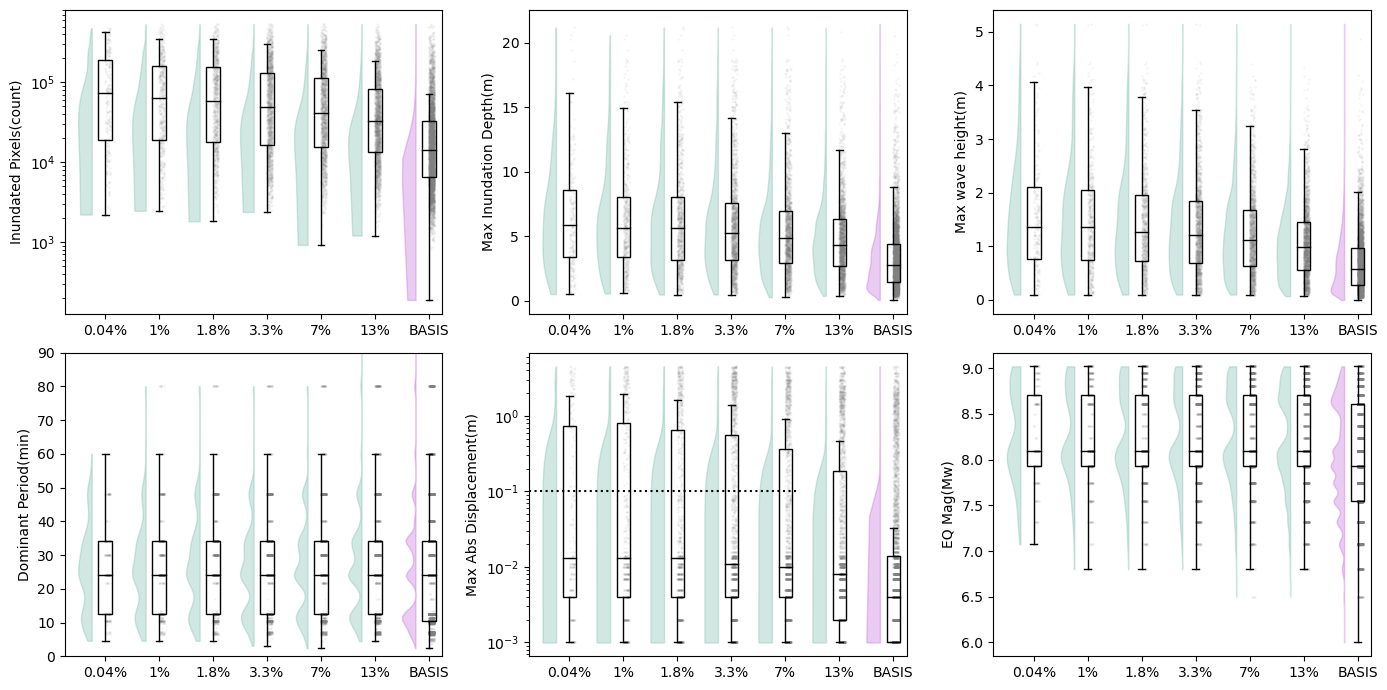

In [41]:
fig, axs = plt.subplots(2, 3, figsize=(14,7))
for i, var in enumerate(variables):
    ax = axs.flatten()[i]
    tmp_df = pd.DataFrame({labels[i]: train_df_CT[var], 'size':train_df_CT['size']})

    #create list of boxplot_data and flatten
    boxplot_data = [[tmp_df[tmp_df["size"] == size][labels[i]].values] for size in ['0','1','2','3','4','5','basis']]
    boxplot_data = [item for sublist in boxplot_data for item in sublist]
    
    # Violinplot data
    vp = ax.violinplot(boxplot_data,showmeans=False, showextrema=False, showmedians=False)
    for idx, b in enumerate(vp['bodies']):
        # Get the center of the plot
        m = np.mean(b.get_paths()[0].vertices[:, 0])
        # Modify it so we only see the left half of the violin plot
        b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], -np.inf, m)
        # Change to the desired color
        if idx == 6: #basis
            b.set_color('mediumorchid')
        else:
            b.set_color('#69b3a2')

    # Scatterplot data, use a random percentage of the data to avoid overplotting
    for idx, features in enumerate(boxplot_data):
        #reduce data points to 10% of the original data for last idx
        if idx ==6 :
            features = features[::10]
        elif idx == 5:
            features = features[::3]
        elif idx == 4:
            features = features[::2]
        else:
            features = features[::1]
        # Add jitter effect so the features do not overlap on the y-axis
        x = np.full(len(features), idx + 1) #some offset
        idxs = np.arange(len(x))
        out = x.astype(float)
        out.flat[idxs] += np.random.uniform(low=-0.05, high=.05, size=len(idxs))
        x = out+0.3
        ax.scatter(x,features, s=1, color='grey', alpha=0.05)

    bp = ax.boxplot(boxplot_data,patch_artist=True,showfliers=False, positions=[1.25,2.25,3.25,4.25,5.25,6.25,7.25],
            boxprops=dict(facecolor='none', color='k',linewidth=1),
            medianprops=dict(color='k',linewidth=1),
            widths=0.25,
            flierprops=dict(marker='d', markerfacecolor='r',markersize=3,alpha=0.005,linestyle='none'),
            whiskerprops=dict(color='k',linewidth=1),
            capprops=dict(color='k',linewidth=1),)
    ax.set_xlabel('')
    ax.set_xticklabels(['0.04%','1%','1.8%','3.3%','7%','13%','BASIS'])
    ax.set_ylabel(labels[i])
    if i == 0:
        #set values as scientific notation
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,1))
        ax.set_yscale('log')
    if i ==4:
        #set y values as specific values, as streched
        ax.set_yscale('log')
        ax.hlines(0.1,0.5,5.5,linestyles='dotted',color='k')
    if i ==3:
        #set x limit for dominant period
        ax.set_ylim(0,90)
    #add padding to x-axis
    ax.set_xlim(0.5,7.5)
plt.tight_layout()
plt.savefig('./boxplot_CT_trainbasis.png',dpi=600)

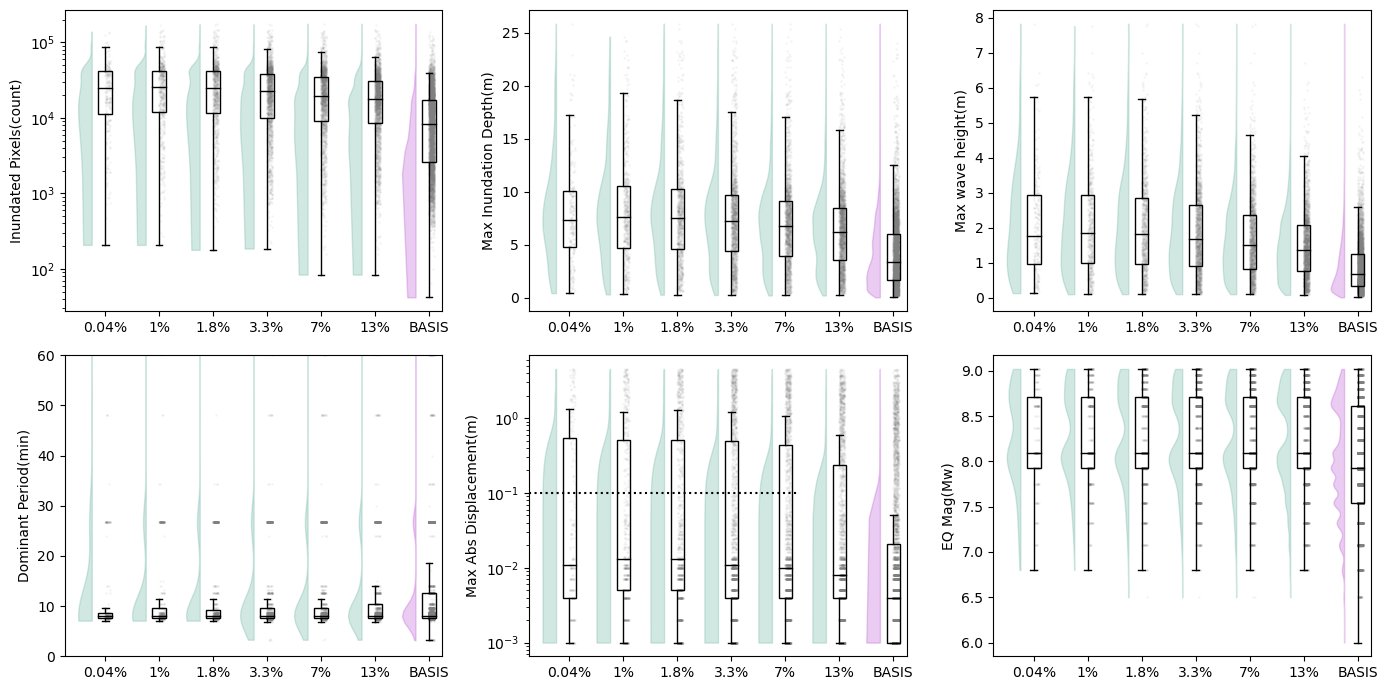

In [40]:
fig, axs = plt.subplots(2, 3, figsize=(14,7))
for i, var in enumerate(variables):
    ax = axs.flatten()[i]
    tmp_df = pd.DataFrame({labels[i]: train_df_SR[var], 'size':train_df_SR['size']})

    #create list of boxplot_data and flatten
    boxplot_data = [[tmp_df[tmp_df["size"] == size][labels[i]].values] for size in ['0','1','2','3','4','5','basis']]
    boxplot_data = [item for sublist in boxplot_data for item in sublist]
    
    # Violinplot data
    vp = ax.violinplot(boxplot_data,showmeans=False, showextrema=False, showmedians=False)
    for idx, b in enumerate(vp['bodies']):
        # Get the center of the plot
        m = np.mean(b.get_paths()[0].vertices[:, 0])
        # Modify it so we only see the left half of the violin plot
        b.get_paths()[0].vertices[:, 0] = np.clip(b.get_paths()[0].vertices[:, 0], -np.inf, m)
        # Change to the desired color
        if idx == 6: #basis
            b.set_color('mediumorchid')
        else:
            b.set_color('#69b3a2')

    # Scatterplot data, use a random percentage of the data to avoid overplotting
    for idx, features in enumerate(boxplot_data):
        #reduce data points to 10% of the original data for last idx
        if idx ==6 :
            features = features[::10]
        elif idx == 5:
            features = features[::3]
        elif idx == 4:
            features = features[::2]
        else:
            features = features[::1]
        # Add jitter effect so the features do not overlap on the y-axis
        x = np.full(len(features), idx + 1) #some offset
        idxs = np.arange(len(x))
        out = x.astype(float)
        out.flat[idxs] += np.random.uniform(low=-0.05, high=.05, size=len(idxs))
        x = out+0.3
        ax.scatter(x,features, s=1, color='grey', alpha=0.05)

    bp = ax.boxplot(boxplot_data,patch_artist=True,showfliers=False, positions=[1.25,2.25,3.25,4.25,5.25,6.25,7.25],
            boxprops=dict(facecolor='none', color='k',linewidth=1),
            medianprops=dict(color='k',linewidth=1),
            widths=0.25,
            flierprops=dict(marker='d', markerfacecolor='r',markersize=3,alpha=0.005,linestyle='none'),
            whiskerprops=dict(color='k',linewidth=1),
            capprops=dict(color='k',linewidth=1),)
    ax.set_xlabel('')
    ax.set_xticklabels(['0.04%','1%','1.8%','3.3%','7%','13%','BASIS'])
    ax.set_ylabel(labels[i])
    if i == 0:
        #set values as scientific notation
        ax.ticklabel_format(axis='y', style='sci', scilimits=(0,1))
        ax.set_yscale('log')
    if i ==4:
        #set y values as specific values, as streched
        ax.set_yscale('log')
        ax.hlines(0.1,0.5,5.5,linestyles='dotted',color='k')
    if i ==3:
        #set x limit for dominant period
        ax.set_ylim(0,60)
    #add padding to x-axis
    ax.set_xlim(0.5,7.5)
plt.tight_layout()
plt.savefig('./boxplot_SR_trainbasis.png',dpi=600)